`Агент` — система, которая принимает решения, исходя из внутреннего состояния (стратегии) и функции ценности перспективности текущего состояния. Агент отвечает исключительно за генерацию Действия A(t) на основе полученного от среды Наблюдения S(t) или O(t). Не имеет прямого контроля над законами физики среды или логикой перехода состояний — он может влиять на них только опосредованно через свои действия.

`Среда` — динамическая система (симулятор, игровой движок или физический мир), которая принимает на вход действия агента, изменяет свое внутреннее состояние по правилам свой транзитивной модели и возвращает обратную связь. Среда полностью изолирована от внутренней логики агента. Её задача — рассчитать следующий шаг симуляции, выдать агенту новое состояние S {t+1} и рассчитать скалярный сигнал подкрепления — награду R {t+1}. 

Среда задает: 
- S пространство состояний  

- A пространство действий  

- P функцию переходов  

- R функцию наград  

- **Сигнал вознаграждения.** Число, которое среда отправляет агенту на каждом шаге. Определяет цель: задача агента — максимизировать ожидаемое совокупное вознаграждение, которое является единственной обратной связью, которую получает агент. Вознаграждение устанавливается средой, а не выбирается агентом.
    
- **Политика.** Правило принятия решений агентом, связывающее ситуации с действиями. Политика - это то, что агент на самом деле делает; все остальное существует для поиска подходящего варианта. Он может быть детерминированным ("всегда идти направо в этом состоянии") или стохастическим ("идти направо с вероятностью 0,7"). Он может быть представлен справочной таблицей, или простой функцией для небольших задач, или нейронной сетью в современном RL.
    
- **Функция ценности.** Если сигнал вознаграждения говорит о том, что хорошо _прямо сейчас_, то функция ценности говорит о том, что хорошо _в долгосрочной перспективе_. Состояние с нулевым немедленным вознаграждением все равно может иметь высокую ценность, поскольку оно ведет к состояниям, которые приносят большое вознаграждение. Большинство алгоритмов, описанных в этом руководстве, основаны на точной оценке функций полезности, поскольку, если можно предсказать долгосрочное вознаграждение, выбор действий сводится к выбору того, которое принесет наибольшую выгоду.
    
- **Модель.** Необязательное внутреннее описание среды: учитывая состояние и действие, какое состояние и награда последуют дальше. Методы, которые изучают и используют эту информацию, называются **основанными на моделях**; методы, которые работают непосредственно на основе опыта, являются **безмодельными**. Методы, основанные на моделях, позволяют планировать, моделируя возможное будущее, прежде чем действовать, методы без моделей полностью пропускают модель и учатся непосредственно на опыте.
    

Вознаграждение R{t+1} — это единственный сигнал обратной связи. Здесь нет пометок, исправлений или объяснений. На каждом этапе — одно число. Задача агента — максимизировать общее вознаграждение, которое он получает с течением времени.

`Траектории` — это основная единица данных в обучении с подкреплением (цикл действий в среде): в то время как обучение с учителем предполагает использование фиксированного набора размеченных примеров.

#### Возврат и скидки

Однако приведенное выше утверждение требует двух уточнений.

Во-первых, окружающая среда стохастична. Даже при использовании фиксированной стратегии одна и та же исходная ситуация может привести к совершенно разным траекториям — например, из-за люфта в суставе робота, броска кубика в игре или зашумленных показаний датчика. Таким образом, общая награда по любой отдельной траектории является случайной величиной, и агент не может максимизировать ее напрямую. Он может только максимизировать **ожидаемое значение** по всем траекториям, которые порождает его стратегия.

Во-вторых, «общее вознаграждение» должно по-разному оценивать вознаграждения, полученные в ближайшем и отдаленном будущем. Рассматривать вознаграждение, которое будет получено через десять шагов, так же, как вознаграждение, которое будет получено сейчас, — это непрактично (отсроченные выплаты обычно должны иметь меньший вес) и неудобно с математической точки зрения (сумма может не сходиться для задач, которые никогда не заканчиваются).

Проще говоря: вознаграждение в ближайшем будущем ценится больше, чем вознаграждение в отдаленном будущем

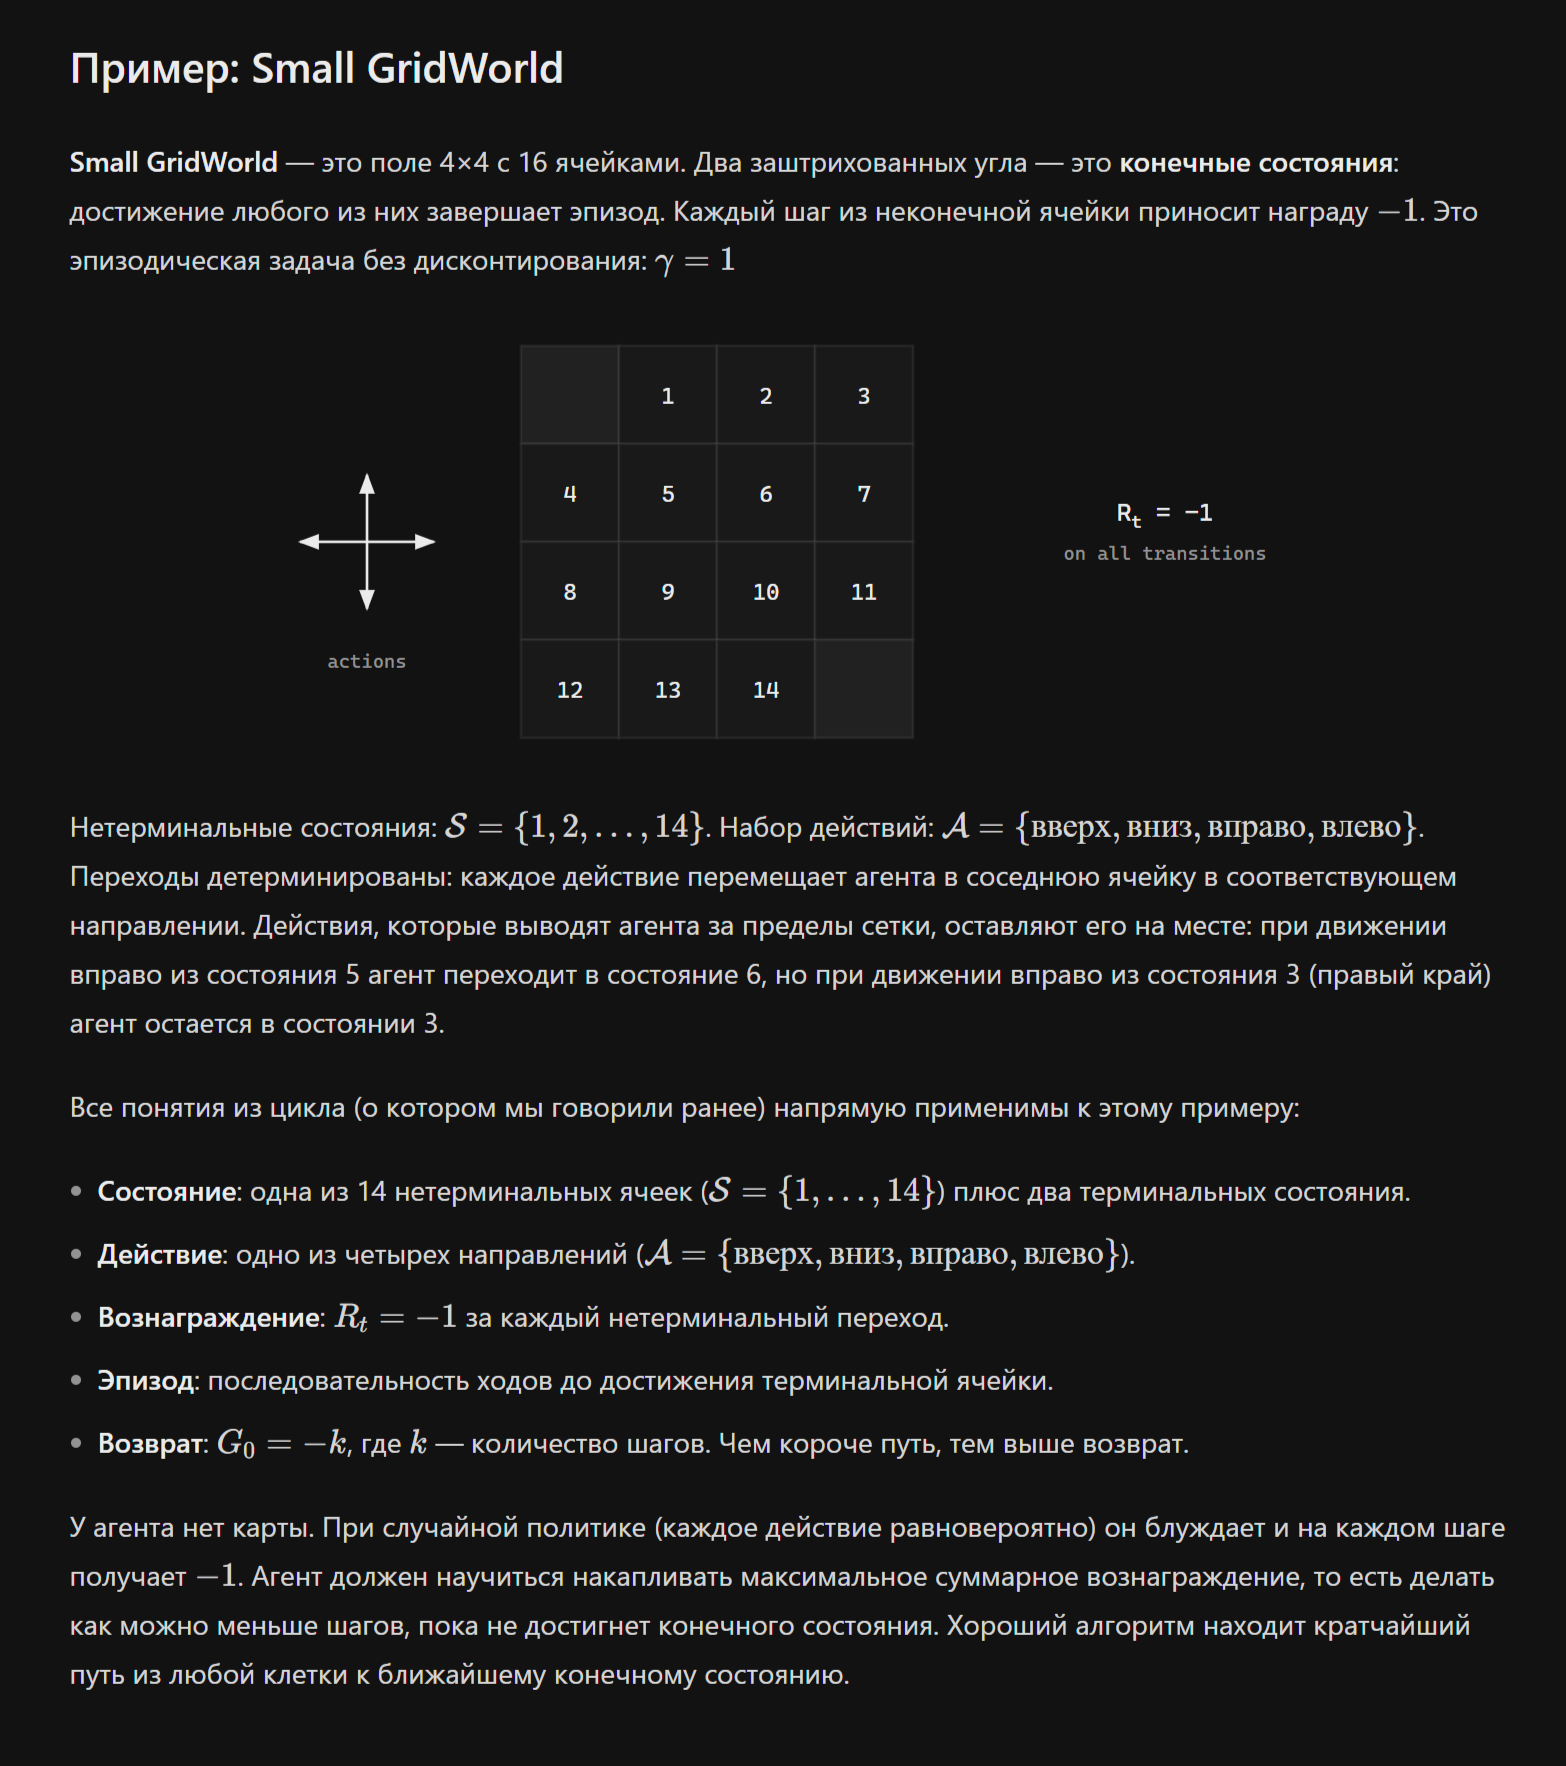

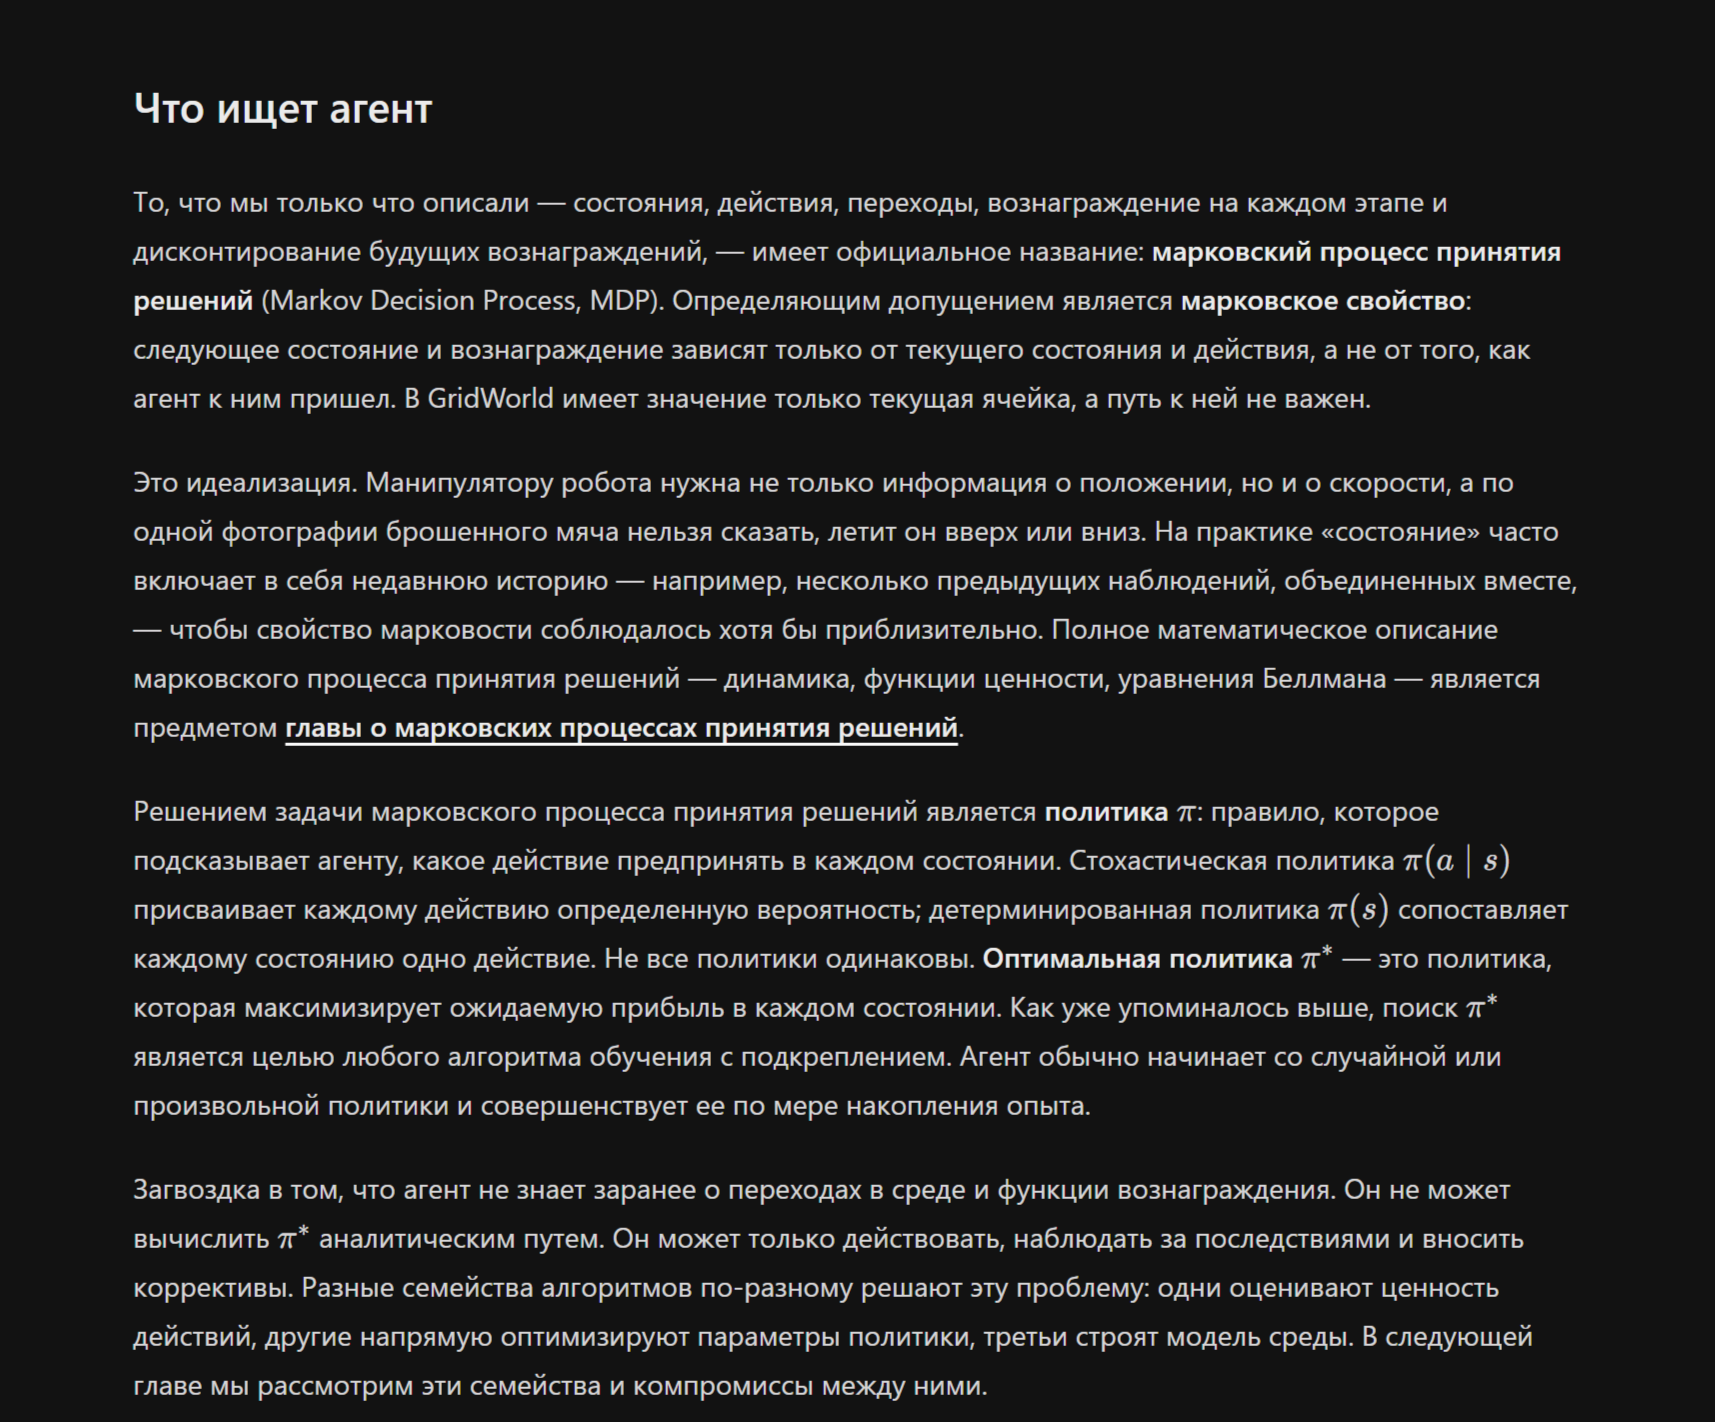

### Методы обучения с подкреплением

**Аннотация.** Область обучения с подкреплением распалась на множество семейств алгоритмов, каждое из которых имеет свои компромиссы. В этой главе мы сопоставляем эти семейства по трем критериям: использует ли агент явную модель среды, какой объект он изучает и может ли он повторно использовать данные, собранные предыдущими политиками? Сопоставление также соответствует текущей структуре руководства: сначала методы, основанные на ценности, затем методы, основанные на политике, далее методы, основанные на политике, и, наконец, методы, основанные на модели, и расширенные настройки.